<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_09_CNN_Dataset_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Notebook Overview

In [1]:
# ============================================================
# Notebook 09
# CNN Dataset Pipeline
# ============================================================

# This notebook prepares TensorFlow datasets for CNN training.
#
# Input:
#   train.csv
#   validation.csv
#   test.csv
#
# Output:
#   tf.data.Dataset objects
#
# Models using this pipeline:
#   - EfficientNetB0
#   - DenseNet121
#   - ResNet50
#
# ============================================================

##2. Mount Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!nvidia-smi

Thu Jul 23 23:17:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##3. Import Libraries

In [5]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


##4. Define Paths

In [6]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

PROCESSED_PATH = (
    DRIVE_ROOT /
    "Dataset" /
    "Processed"
)

TRAIN_CSV = PROCESSED_PATH / "train.csv"

VALIDATION_CSV = PROCESSED_PATH / "validation.csv"

TEST_CSV = PROCESSED_PATH / "test.csv"

##5. Load CSV Files

In [7]:
train_df = pd.read_csv(TRAIN_CSV)

validation_df = pd.read_csv(VALIDATION_CSV)

test_df = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (1450, 5)
Validation: (309, 5)
Test: (280, 5)


##6. Verify Class Distribution

In [8]:
print("=" * 50)

print("TRAIN")
print(train_df["LabelName"].value_counts())

print()

print("VALIDATION")
print(validation_df["LabelName"].value_counts())

print()

print("TEST")
print(test_df["LabelName"].value_counts())

TRAIN
LabelName
Benign       1256
Malignant     194
Name: count, dtype: int64

VALIDATION
LabelName
Benign       272
Malignant     37
Name: count, dtype: int64

TEST
LabelName
Benign       246
Malignant     34
Name: count, dtype: int64


##7. Compute Class Weights

In [9]:
classes = np.unique(train_df["CancerLabel"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["CancerLabel"]
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5772292993630573), np.int64(1): np.float64(3.7371134020618557)}


##8. Global Configuration

In [10]:
# ============================================================
# Section 8 - Global Configuration
# ============================================================

IMAGE_SIZE = (128, 128)

BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

print("Image Size :", IMAGE_SIZE)

print("Batch Size :", BATCH_SIZE)

Image Size : (128, 128)
Batch Size : 16


##9. Image Loading Function

In [11]:
# ============================================================
# Section 9 - Read PNG Image
# ============================================================

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    return image, label

##10. Data Augmentation

In [12]:
# ============================================================
# Section 10 - Data Augmentation
# ============================================================

augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.05
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomTranslation(
        0.05,
        0.05
    )

])

##11. Apply Augmentation

In [13]:
# ============================================================
# Section 11 - Apply Augmentation
# ============================================================

def augment(image, label):

    image = augmentation(
        image,
        training=True
    )

    return image, label

##12. Dataset Builder

In [14]:
# ============================================================
# Section 12 - Build TensorFlow Dataset
# ============================================================

def build_dataset(df, training=False):

    paths = df["ImagePath"].values

    labels = df["CancerLabel"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:

        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42
        )

        ds = ds.map(
            augment,
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds

##13. Create Datasets

In [15]:
# ============================================================
# Section 13 - Create Datasets
# ============================================================

train_ds = build_dataset(
    train_df,
    training=True
)

validation_ds = build_dataset(
    validation_df
)

test_ds = build_dataset(
    test_df
)

print(train_ds)

print(validation_ds)

print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


##14. Inspect One Batch

In [16]:
# ============================================================
# Section 14 - Inspect Batch
# ============================================================

images, labels = next(iter(train_ds))

print("Images:", images.shape)

print("Labels:", labels.shape)

print(images.dtype)

print(images.numpy().min())

print(images.numpy().max())

Images: (16, 128, 128, 3)
Labels: (16,)
<dtype: 'float32'>
0.0
1.0


##15. Visualize Augmented Images

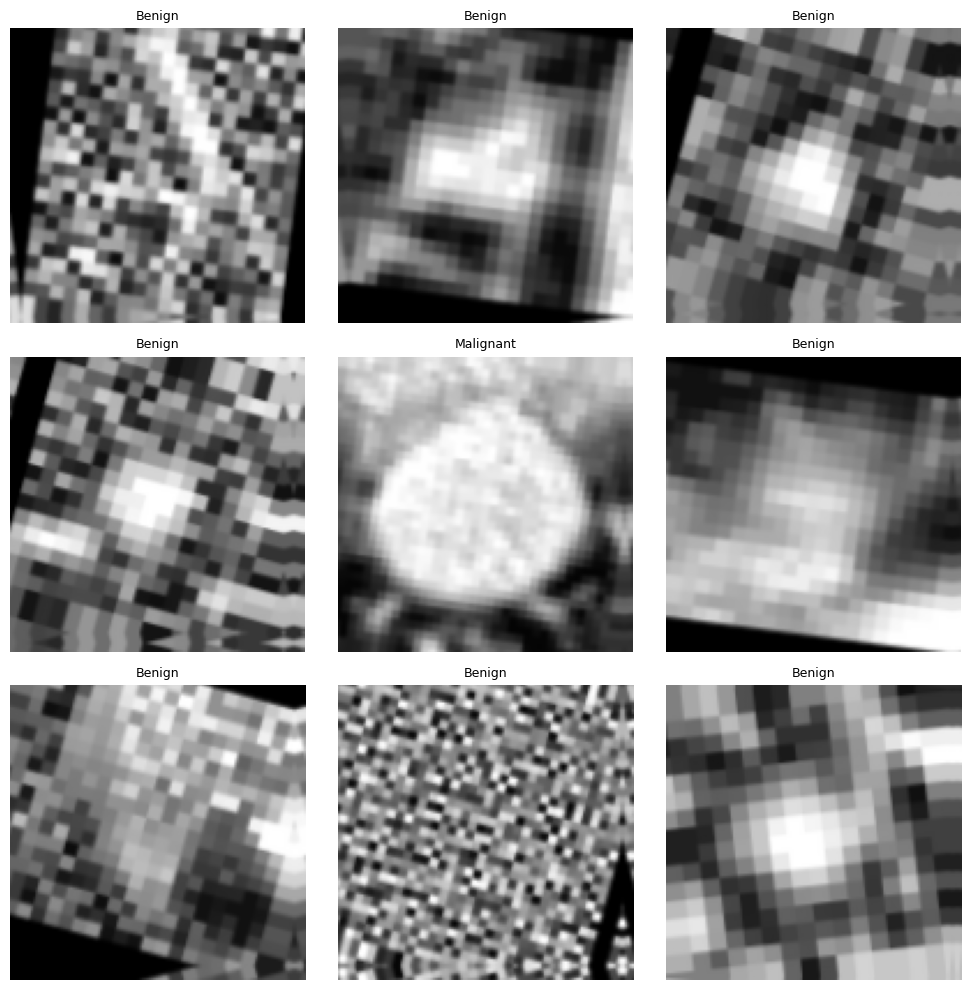

In [17]:
# ============================================================
# Section 15 - Visualize Batch
# ============================================================

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        "Malignant" if labels[i] else "Benign",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()